## classification 

In [99]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import confusion_matrix

# New cell (index 0) - train a simple NN for 4-class classification

# reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# load data (assumes files are in working directory)
X = pd.read_csv(r'C:\Users\ISHAN\ML\DL Project\input_features.csv')
y = pd.read_csv(r'C:\Users\ISHAN\ML\DL Project\stress_classifications.csv').squeeze().astype(int)  # expects values 0,1,2,3

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [100]:

# build model
input_dim = X_train.shape[1]
model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    # layers.BatchNormalization(),
    # layers.Dropout(0.2),
    # layers.Dense(22, activation="relu"),

    layers.Dense(4, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# callbacks
es = callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_loss")
model.summary()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_80 (Dense)                │ (None, 512)            │       116,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 294,756 (1.12 MB)

 Trainable params: 292,836 (1.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [101]:

# train
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=150,
    batch_size=64,
    callbacks=[es],
    verbose=2
)

# evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {loss:.4f}, Test accuracy: {acc:.4f}")

# detailed classification report
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, digits=4))


Epoch 1/150
54/54 - 3s - 55ms/step - accuracy: 0.3351 - loss: 1.5190 - val_accuracy: 0.5067 - val_loss: 1.1524
Epoch 2/150
54/54 - 0s - 6ms/step - accuracy: 0.5481 - loss: 1.0423 - val_accuracy: 0.5383 - val_loss: 1.0249
Epoch 3/150
54/54 - 0s - 5ms/step - accuracy: 0.5943 - loss: 0.9142 - val_accuracy: 0.5867 - val_loss: 0.9196
Epoch 4/150
54/54 - 0s - 5ms/step - accuracy: 0.6617 - loss: 0.7792 - val_accuracy: 0.6050 - val_loss: 0.8494
Epoch 5/150
54/54 - 0s - 5ms/step - accuracy: 0.7129 - loss: 0.6701 - val_accuracy: 0.6283 - val_loss: 0.8320
Epoch 6/150
54/54 - 0s - 5ms/step - accuracy: 0.7367 - loss: 0.6109 - val_accuracy: 0.6317 - val_loss: 0.8212
Epoch 7/150
54/54 - 0s - 5ms/step - accuracy: 0.7870 - loss: 0.5388 - val_accuracy: 0.6317 - val_loss: 0.8636
Epoch 8/150
54/54 - 0s - 5ms/step - accuracy: 0.8147 - loss: 0.4525 - val_accuracy: 0.6383 - val_loss: 0.9254
Epoch 9/150
54/54 - 0s - 5ms/step - accuracy: 0.8497 - loss: 0.3959 - val_accuracy: 0.6383 - val_loss: 0.9289
Epoch 10/

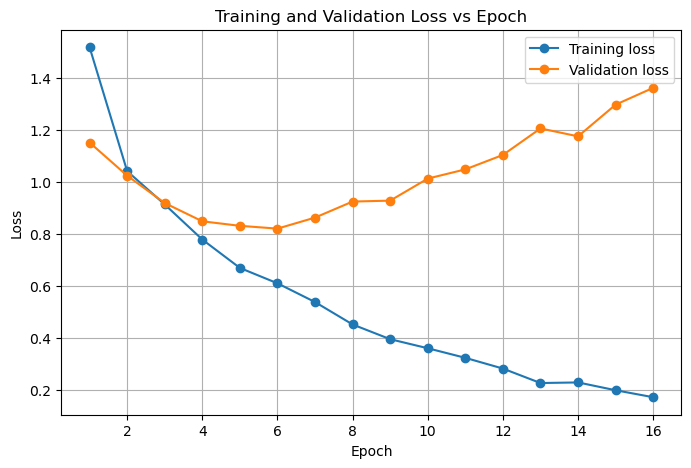

In [102]:

# plot training & validation loss vs epochs (treating loss as error)
loss = history.history.get("loss", [])
val_loss = history.history.get("val_loss", [])
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label="Training loss", marker="o")
plt.plot(epochs, val_loss, label="Validation loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

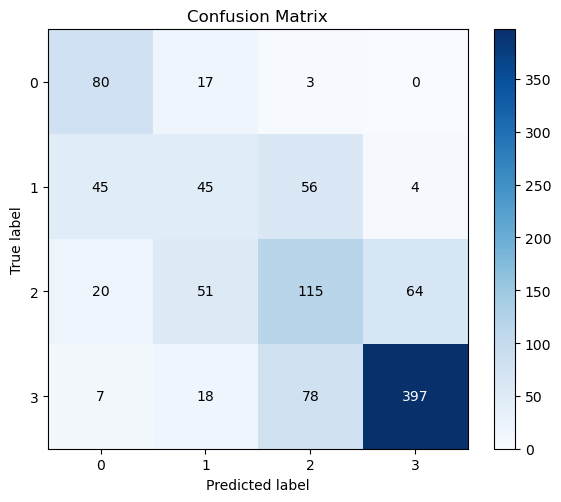

In [103]:
cm = confusion_matrix(y_test, y_pred)
classes = np.arange(4)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)
plt.ylabel("True label")
plt.xlabel("Predicted label")

thresh = cm.max() / 2.0
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], "d"),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

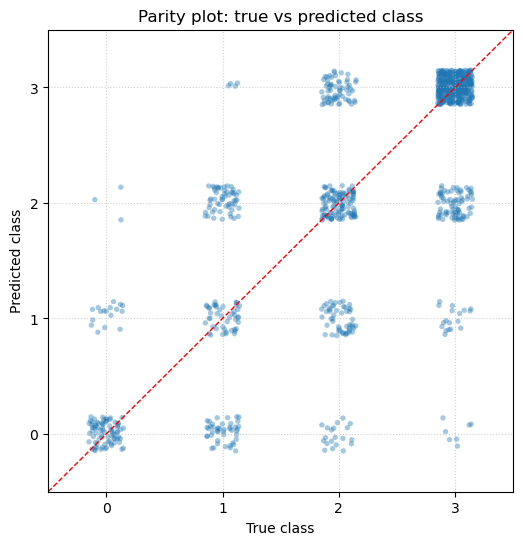

In [104]:
true_labels = y_test.to_numpy(dtype=int)
pred_labels = y_pred.astype(int)

jitter = 0.15
x = true_labels + np.random.uniform(-jitter, jitter, size=true_labels.shape)
y_ = pred_labels + np.random.uniform(-jitter, jitter, size=pred_labels.shape)

plt.figure(figsize=(6, 6))
plt.scatter(x, y_, alpha=0.4, s=15, edgecolor="none")
plt.plot([-0.5, 3.5], [-0.5, 3.5], color="red", linestyle="--", linewidth=1)
plt.xticks(classes)
plt.yticks(classes)
plt.xlim(-0.5, 3.5)
plt.ylim(-0.5, 3.5)
plt.xlabel("True class")
plt.ylabel("Predicted class")
plt.title("Parity plot: true vs predicted class")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()